### prep chai array-like

In [1]:
import pandas as pd
import yaml
from pathlib import Path

YAML_PATH = "/home/bri/pymol/EDA/static/metric_directions.yaml"
OUTPUT_DIR = Path("/home/bri/pymol/EDA/static/harvey_outputs")
OUTPUT_DIR.mkdir(exist_ok=True)

CSV_PATH =  "/home/bri/pymol/EDA/static/harvey_outputs/merged_harvey.csv"
scores_df = pd.read_csv(CSV_PATH)

scores_df.head()

,source,type,binder,KD[M],EC50[M],sample,af3_pae,af3_plddt,af3_interface_dG,af3_interface_dG_SASA_ratio,...,boltz_template_ipde,boltz_template_per_chain_pair_iptm,boltz_template_ipsae,boltz_template_pdockq,boltz_template_pdockq2,boltz_template_lis,chai_unconstrained_per_chain_ptm,chai_unconstrained_per_chain_pair_iptm,chai_constrained_per_chain_ptm,chai_constrained_per_chain_pair_iptm
0,harvey,original,1.0,NaN,NaN,AT118i4h32_AGTR1,11.528240,78.049861,241.77,7.91,...,0.649316,0.953019,0.871298,0.5023,0.5615,0.6842,"[[0.8844592571258545, 0.7967235445976257]]","[[[0.8844592571258545, 0.45740675926208496], [...","[[0.899858832359314, 0.9029654264450073]]","[[[0.899858832359314, 0.7897694110870361], [0...."
1,harvey,original,1.0,NaN,NaN,AT201_AGTR1,12.212700,76.021409,108.25,7.19,...,2.173097,0.910365,0.755096,0.4618,0.3734,0.5413,"[[0.885317325592041, 0.7817205786705017]]","[[[0.885317325592041, 0.19592402875423431], [0...","[[0.8954206705093384, 0.82906174659729]]","[[[0.8954206705093384, 0.5672476887702942], [0..."
2,harvey,original,1.0,NaN,NaN,AT202_AGTR1,13.119915,76.458147,299.89,11.87,...,4.002924,0.822987,0.587241,0.6138,0.2044,0.4111,"[[0.8855280876159668, 0.7832863926887512]]","[[[0.8855280876159668, 0.22815226018428802], [...","[[0.8752248883247375, 0.8392460346221924]]","[[[0.8752248883247375, 0.5595718622207642], [0..."
3,harvey,original,1.0,NaN,NaN,AT203_AGTR1,11.603302,78.053494,77.77,2.87,...,1.497975,0.910428,0.795326,0.6598,0.6871,0.5950,"[[0.862318754196167, 0.8046218156814575]]","[[[0.862318754196167, 0.37608620524406433], [0...","[[0.8754035830497742, 0.8123531937599182]]","[[[0.8754035830497742, 0.6163707971572876], [0..."
4,harvey,original,1.0,NaN,NaN,AT204_AGTR1,16.662872,71.692176,456.19,24.69,...,3.520961,0.815329,0.557721,0.5336,0.2333,0.4120,"[[0.9009032845497131, 0.7990964651107788]]","[[[0.9009032845497131, 0.2246391326189041], [0...","[[0.9041344523429871, 0.8222752809524536]]","[[[0.9041344523429871, 0.6109544038772583], [0..."


### prep chai array-like

In [2]:
chai_df = scores_df[['sample', 'chai_unconstrained_per_chain_ptm', 'chai_unconstrained_per_chain_pair_iptm', 'chai_constrained_per_chain_ptm', 'chai_constrained_per_chain_pair_iptm']]
chai_df.to_csv(OUTPUT_DIR / 'chai_matrices.csv', index=False)
#chai_df.head()

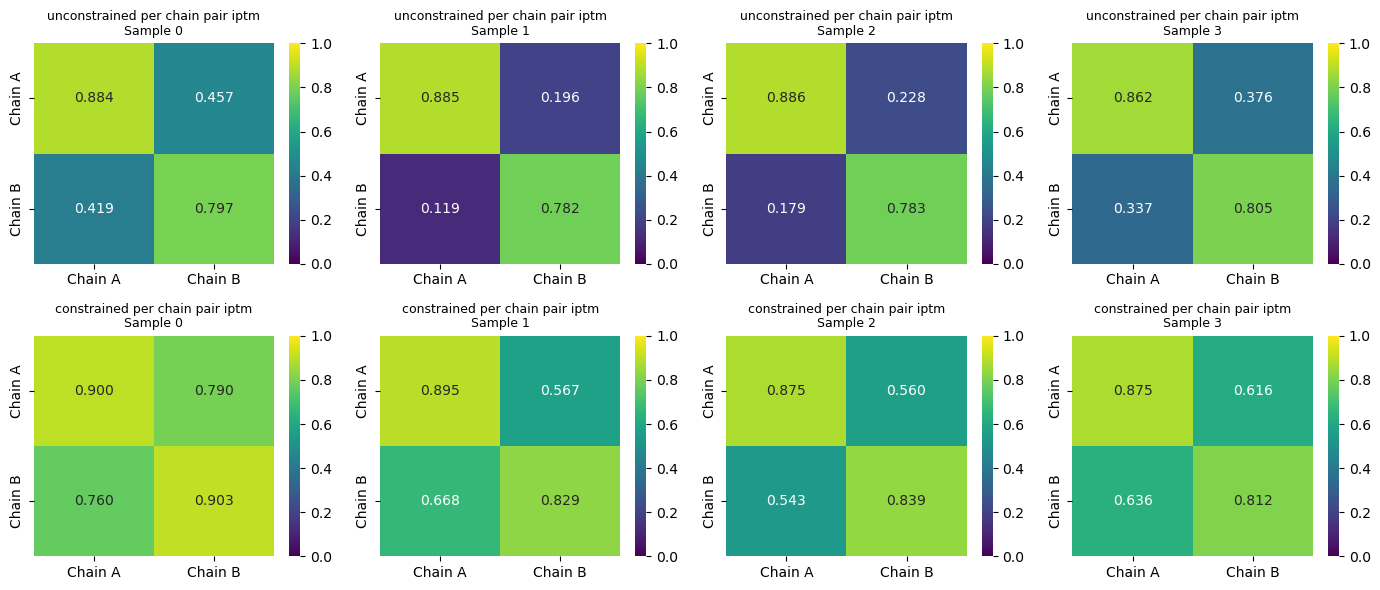

In [3]:
# Parse matrix strings from all 4 chai columns
import ast
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

def parse_matrix(x):
    if pd.isna(x):
        return None
    try:
        arr = np.array(ast.literal_eval(x))
        return arr.squeeze()  # remove extra dimensions
    except:
        return None

# Apply parse_matrix to all 4 columns
ptm_cols = ['chai_unconstrained_per_chain_ptm', 'chai_unconstrained_per_chain_pair_iptm', 'chai_constrained_per_chain_ptm', 'chai_constrained_per_chain_pair_iptm']

for col in ptm_cols:
    chai_df[f"{col}_matrix"] = chai_df[col].apply(parse_matrix)

# Create heatmaps for first 4 samples (focusing on pair_iptm columns)
pair_cols = ['chai_unconstrained_per_chain_pair_iptm', 'chai_constrained_per_chain_pair_iptm']

fig, axes = plt.subplots(2, 4, figsize=(14, 6))

for row_idx, col in enumerate(pair_cols):
    for sample_idx in range(4):
        ax = axes[row_idx, sample_idx]
        matrix = chai_df[f"{col}_matrix"].iloc[sample_idx]
        
        if matrix is not None and isinstance(matrix, np.ndarray) and matrix.ndim == 2:
            n = matrix.shape[0]  # works for 2x2, 3x3, etc.
            labels = [f'Chain {chr(65+i)}' for i in range(n)]  # A, B, C, ...
            
            sns.heatmap(
                matrix,
                ax=ax,
                cmap='viridis',
                cbar=True,
                xticklabels=labels,
                yticklabels=labels,
                vmin=0,
                vmax=1,
                annot=True,
                fmt='.3f'
            )
            
            ax.set_title(
                f'{col.replace("chai_", "").replace("_", " ")}\nSample {sample_idx}',
                fontsize=9
            )
        else:
            ax.text(0.5, 0.5, 'No data', ha='center', va='center')
            ax.set_xticks([])
            ax.set_yticks([])


plt.tight_layout()
plt.savefig(OUTPUT_DIR /'chai_matrices_heatmaps.png', dpi=150, bbox_inches='tight')
plt.show()



In [4]:
def extract_matrix_min(matrix):
    if matrix is None or not isinstance(matrix, np.ndarray) or matrix.ndim != 2:
        return np.nan

    n = matrix.shape[0]

    # germinal/mcmahon: only one interface (A-C or B-C)
    if n == 2:
        return np.min([matrix[0, 1], matrix[1, 0]])

    # snir: average C interactions with A and B
    elif n == 3:
        ac = np.min([matrix[0, 2], matrix[2, 0]])
        bc = np.min([matrix[1, 2], matrix[2, 1]])
        return np.min([ac, bc])

    return np.nan

chai_df['chai_unconstrained_per_chain_pair_iptm'] = \
    chai_df['chai_unconstrained_per_chain_pair_iptm_matrix'].apply(extract_matrix_min)

chai_df['chai_constrained_per_chain_pair_iptm'] = \
    chai_df['chai_constrained_per_chain_pair_iptm_matrix'].apply(extract_matrix_min)


# Display summary
print("Unconstrained A-B interface min (top 10):")
print(chai_df['chai_unconstrained_per_chain_pair_iptm'].head(10).to_string())
print("\nConstrained A-B interface min (top 10):")
print(chai_df['chai_constrained_per_chain_pair_iptm'].head(10).to_string())

Unconstrained A-B interface min (top 10):
0    0.419045
1    0.118825
2    0.179008
3    0.337474
4    0.142731
5    0.271265
6    0.618950
7    0.480093
8    0.645558
9    0.376706

Constrained A-B interface min (top 10):
0    0.759819
1    0.567248
2    0.542771
3    0.616371
4    0.556965
5    0.600102
6    0.668770
7    0.563248
8    0.610894
9    0.721330


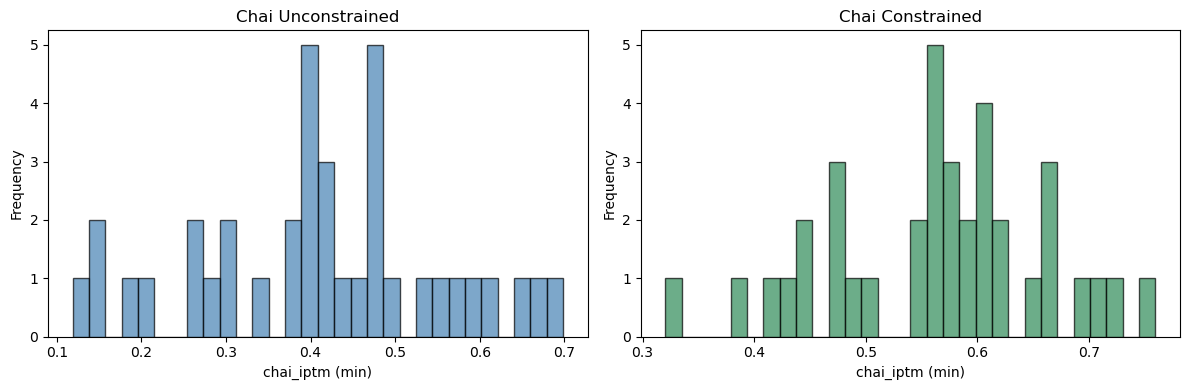

In [5]:
# Visualize the distribution
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(chai_df['chai_unconstrained_per_chain_pair_iptm'].dropna(), bins=30, alpha=0.7, color='steelblue', edgecolor='black')
axes[0].set_xlabel('chai_iptm (min)')
axes[0].set_ylabel('Frequency')
axes[0].set_title('Chai Unconstrained')
axes[0].grid(False)

axes[1].hist(chai_df['chai_constrained_per_chain_pair_iptm'].dropna(), bins=30, alpha=0.7, color='seagreen', edgecolor='black')
axes[1].set_xlabel('chai_iptm (min)')
axes[1].set_ylabel('Frequency')
axes[1].set_title('Chai Constrained')
axes[1].grid(False)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'chai_iptm_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

In [6]:
# Extract min pTM
def extract_ptm_min(arr):
    """Extract minimum of pTM array (average across both chains)"""
    if arr is None or not isinstance(arr, np.ndarray) or arr.ndim != 1:
        return np.nan
    return np.min(arr)

# Extract min for unconstrained pTM
chai_df['chai_unconstrained_per_chain_ptm'] = \
    chai_df['chai_unconstrained_per_chain_ptm_matrix'].apply(extract_ptm_min)

# Extract min for constrained pTM
chai_df['chai_constrained_per_chain_ptm'] = \
    chai_df['chai_constrained_per_chain_ptm_matrix'].apply(extract_ptm_min)

# Display summary

print("\nUnconstrained pTM min (top 10):")
print(chai_df['chai_unconstrained_per_chain_ptm'].head(10).to_string())
print("\nConstrained pTM min (top 10):")
print(chai_df['chai_constrained_per_chain_ptm'].head(10).to_string())
print(f"\nUnconstrained pTM min - desc stats:\n{chai_df['chai_unconstrained_per_chain_ptm'].describe()}")
print(f"\nConstrained pTM min - desc stats:\n{chai_df['chai_constrained_per_chain_ptm'].describe()}")


Unconstrained pTM min (top 10):
0    0.796724
1    0.781721
2    0.783286
3    0.804622
4    0.799096
5    0.797113
6    0.816803
7    0.793810
8    0.825981
9    0.803591

Constrained pTM min (top 10):
0    0.899859
1    0.829062
2    0.839246
3    0.812353
4    0.822275
5    0.815469
6    0.826377
7    0.812038
8    0.827023
9    0.819302

Unconstrained pTM min - desc stats:
count    37.000000
mean      0.820484
std       0.028766
min       0.744111
25%       0.799096
50%       0.829755
75%       0.841339
max       0.866754
Name: chai_unconstrained_per_chain_ptm, dtype: float64

Constrained pTM min - desc stats:
count    37.000000
mean      0.835068
std       0.023326
min       0.776139
25%       0.822275
50%       0.835848
75%       0.845774
max       0.899859
Name: chai_constrained_per_chain_ptm, dtype: float64


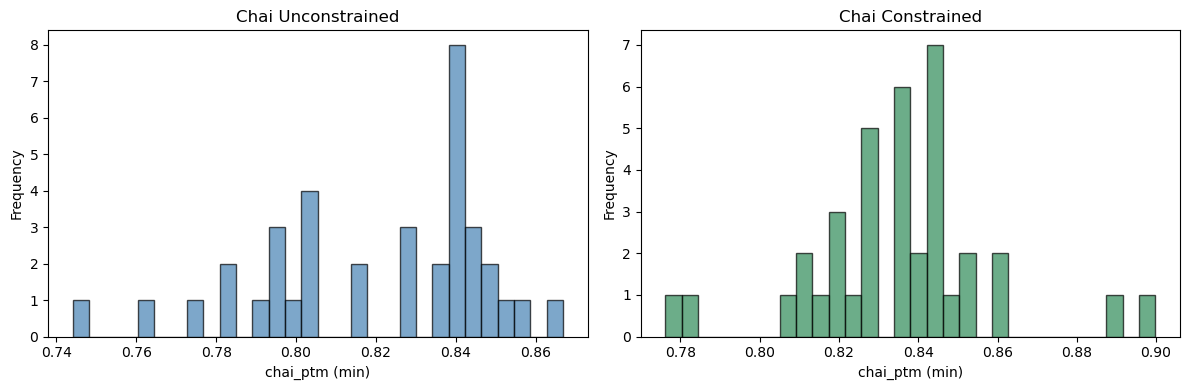

In [7]:
# Visualize the distribution
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(chai_df['chai_unconstrained_per_chain_ptm'].dropna(), bins=30, alpha=0.7, color='steelblue', edgecolor='black')
axes[0].set_xlabel('chai_ptm (min)')
axes[0].set_ylabel('Frequency')
axes[0].set_title('Chai Unconstrained')
axes[0].grid(False)

axes[1].hist(chai_df['chai_constrained_per_chain_ptm'].dropna(), bins=30, alpha=0.7, color='seagreen', edgecolor='black')
axes[1].set_xlabel('chai_ptm (min)')
axes[1].set_ylabel('Frequency')
axes[1].set_title('Chai Constrained')
axes[1].grid(False)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'chai_ptm_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

In [8]:
# Create df_chai_numeric with extracted mean scores 
df_chai_numeric = chai_df[['sample',
                            'chai_unconstrained_per_chain_ptm',
                            'chai_constrained_per_chain_ptm',
                            'chai_unconstrained_per_chain_pair_iptm',
                            'chai_constrained_per_chain_pair_iptm']].copy()

print("df_chai_numeric shape:", df_chai_numeric.shape)
print("\ndf_chai_numeric head:")
print(df_chai_numeric.head(10).to_string())
print("\ndf_chai_numeric info:")
print(df_chai_numeric.info())

# Save to CSV
df_chai_numeric.to_csv(OUTPUT_DIR / 'chai_numeric_metrics.csv', index=False)
print("\n✓ Saved to: chai_numeric_metrics.csv")

df_chai_numeric shape: (37, 5)

df_chai_numeric head:
             sample  chai_unconstrained_per_chain_ptm  chai_constrained_per_chain_ptm  chai_unconstrained_per_chain_pair_iptm  chai_constrained_per_chain_pair_iptm
0  AT118i4h32_AGTR1                          0.796724                        0.899859                                0.419045                              0.759819
1       AT201_AGTR1                          0.781721                        0.829062                                0.118825                              0.567248
2       AT202_AGTR1                          0.783286                        0.839246                                0.179008                              0.542771
3       AT203_AGTR1                          0.804622                        0.812353                                0.337474                              0.616371
4       AT204_AGTR1                          0.799096                        0.822275                                0.142731 

In [9]:
scores_df.drop(columns=['chai_unconstrained_per_chain_ptm', 'chai_unconstrained_per_chain_pair_iptm', 'chai_constrained_per_chain_ptm', 'chai_constrained_per_chain_pair_iptm'], inplace = True)
scores_df.head()

,source,type,binder,KD[M],EC50[M],sample,af3_pae,af3_plddt,af3_interface_dG,af3_interface_dG_SASA_ratio,...,boltz_template_iptm,boltz_template_plddt,boltz_template_iplddt,boltz_template_pde,boltz_template_ipde,boltz_template_per_chain_pair_iptm,boltz_template_ipsae,boltz_template_pdockq,boltz_template_pdockq2,boltz_template_lis
0,harvey,original,1.0,NaN,NaN,AT118i4h32_AGTR1,11.528240,78.049861,241.77,7.91,...,0.953019,0.859860,0.835173,0.455699,0.649316,0.953019,0.871298,0.5023,0.5615,0.6842
1,harvey,original,1.0,NaN,NaN,AT201_AGTR1,12.212700,76.021409,108.25,7.19,...,0.910365,0.895442,0.851292,0.529389,2.173097,0.910365,0.755096,0.4618,0.3734,0.5413
2,harvey,original,1.0,NaN,NaN,AT202_AGTR1,13.119915,76.458147,299.89,11.87,...,0.822987,0.918179,0.874065,0.661224,4.002924,0.822987,0.587241,0.6138,0.2044,0.4111
3,harvey,original,1.0,NaN,NaN,AT203_AGTR1,11.603302,78.053494,77.77,2.87,...,0.910428,0.912280,0.913317,0.602466,1.497975,0.910428,0.795326,0.6598,0.6871,0.5950
4,harvey,original,1.0,NaN,NaN,AT204_AGTR1,16.662872,71.692176,456.19,24.69,...,0.815329,0.893465,0.836321,0.670881,3.520961,0.815329,0.557721,0.5336,0.2333,0.4120


In [10]:
# Join scores_df with df_chai_numeric on "sample"
scores_df_extended = scores_df.merge(df_chai_numeric, on='sample', how='left')

print("Joined DataFrame shape:", scores_df_extended.shape)
print("\nNew columns added from df_chai_numeric:")
new_cols = [col for col in scores_df_extended.columns if col in df_chai_numeric.columns and col != 'sample']
print(new_cols)
print("\nscores_df_extended head:")
print(scores_df_extended[['sample'] + new_cols].head(10).to_string())
print("\nJoin statistics:")
print(f"  - Total rows: {len(scores_df_extended)}")
print(f"  - Rows with all chai metrics: {scores_df_extended[new_cols].notna().all(axis=1).sum()}")
print(f"  - Rows with missing chai metrics: {scores_df_extended[new_cols].isna().any(axis=1).sum()}")

# Save extended dataframe
scores_df_extended.to_csv(OUTPUT_DIR / 'scores_df_extended_with_chai.csv', index=False)
print(f"\n✓ Saved to: {OUTPUT_DIR / 'scores_df_extended_with_chai.csv'}")

Joined DataFrame shape: (37, 91)

New columns added from df_chai_numeric:
['chai_unconstrained_per_chain_ptm', 'chai_constrained_per_chain_ptm', 'chai_unconstrained_per_chain_pair_iptm', 'chai_constrained_per_chain_pair_iptm']

scores_df_extended head:
             sample  chai_unconstrained_per_chain_ptm  chai_constrained_per_chain_ptm  chai_unconstrained_per_chain_pair_iptm  chai_constrained_per_chain_pair_iptm
0  AT118i4h32_AGTR1                          0.796724                        0.899859                                0.419045                              0.759819
1       AT201_AGTR1                          0.781721                        0.829062                                0.118825                              0.567248
2       AT202_AGTR1                          0.783286                        0.839246                                0.179008                              0.542771
3       AT203_AGTR1                          0.804622                        0.812353      

In [11]:
scores_df_extended.head()

,source,type,binder,KD[M],EC50[M],sample,af3_pae,af3_plddt,af3_interface_dG,af3_interface_dG_SASA_ratio,...,boltz_template_ipde,boltz_template_per_chain_pair_iptm,boltz_template_ipsae,boltz_template_pdockq,boltz_template_pdockq2,boltz_template_lis,chai_unconstrained_per_chain_ptm,chai_constrained_per_chain_ptm,chai_unconstrained_per_chain_pair_iptm,chai_constrained_per_chain_pair_iptm
0,harvey,original,1.0,NaN,NaN,AT118i4h32_AGTR1,11.528240,78.049861,241.77,7.91,...,0.649316,0.953019,0.871298,0.5023,0.5615,0.6842,0.796724,0.899859,0.419045,0.759819
1,harvey,original,1.0,NaN,NaN,AT201_AGTR1,12.212700,76.021409,108.25,7.19,...,2.173097,0.910365,0.755096,0.4618,0.3734,0.5413,0.781721,0.829062,0.118825,0.567248
2,harvey,original,1.0,NaN,NaN,AT202_AGTR1,13.119915,76.458147,299.89,11.87,...,4.002924,0.822987,0.587241,0.6138,0.2044,0.4111,0.783286,0.839246,0.179008,0.542771
3,harvey,original,1.0,NaN,NaN,AT203_AGTR1,11.603302,78.053494,77.77,2.87,...,1.497975,0.910428,0.795326,0.6598,0.6871,0.5950,0.804622,0.812353,0.337474,0.616371
4,harvey,original,1.0,NaN,NaN,AT204_AGTR1,16.662872,71.692176,456.19,24.69,...,3.520961,0.815329,0.557721,0.5336,0.2333,0.4120,0.799096,0.822275,0.142731,0.556965


In [12]:
chai_debug = scores_df_extended[['sample', 'chai_unconstrained_per_chain_ptm', 'chai_constrained_per_chain_ptm', 'chai_unconstrained_ptm', 'chai_constrained_ptm', 'chai_unconstrained_per_chain_iptm', 'chai_constrained_per_chain_iptm', 'chai_constrained_interface_iptm',  'chai_unconstrained_interface_iptm', 'chai_unconstrained_iptm', 'chai_constrained_iptm', 'chai_unconstrained_aggregate_score', 'chai_constrained_aggregate_score', 'chai_unconstrained_ipsae', 'chai_constrained_ipsae', 'chai_unconstrained_pdockq', 'chai_constrained_pdockq', 'chai_unconstrained_pdockq2', 'chai_constrained_pdockq2', 'chai_unconstrained_lis', 'chai_constrained_lis']]
chai_debug.head()

KeyError: "['chai_unconstrained_per_chain_iptm', 'chai_constrained_per_chain_iptm'] not in index"

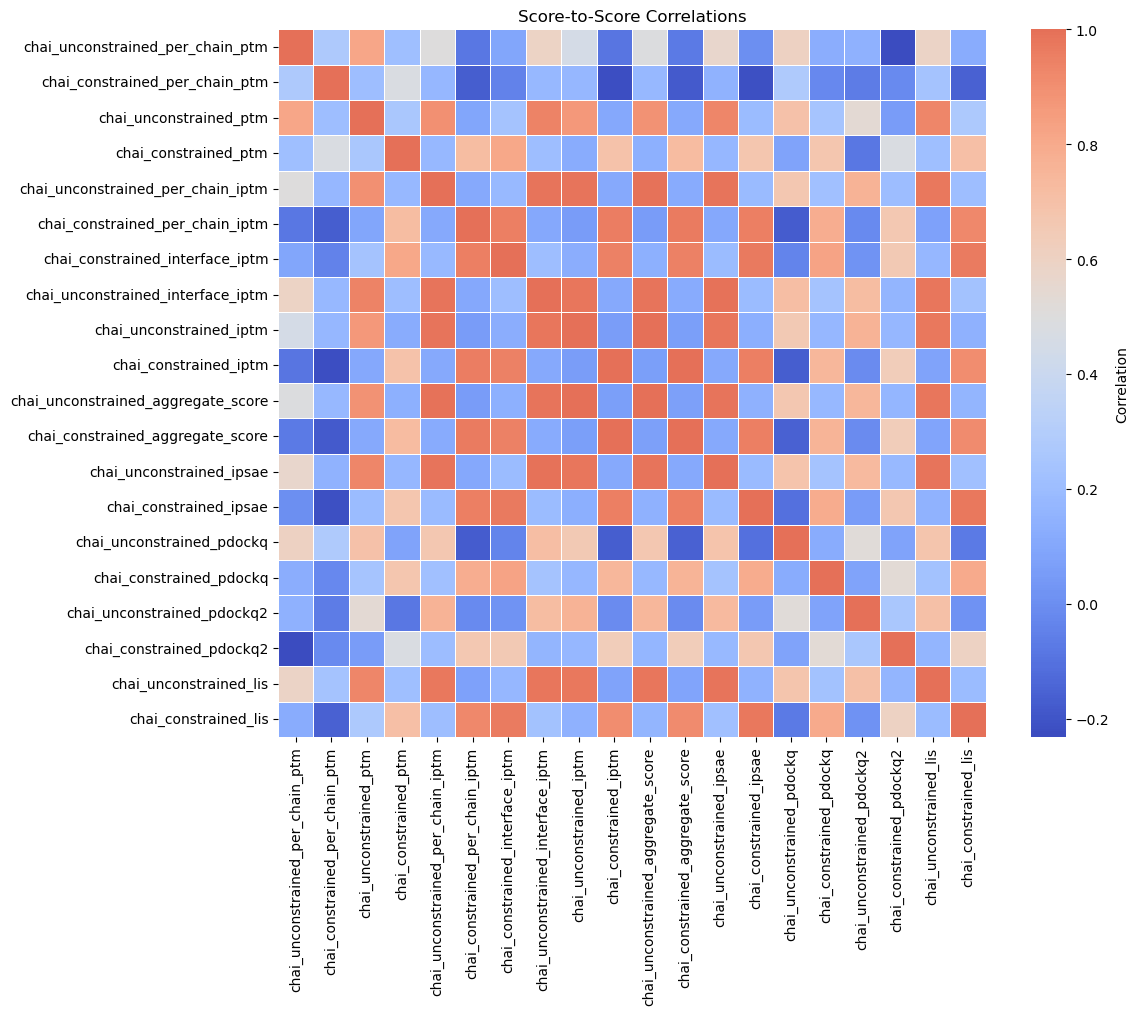

<Figure size 640x480 with 0 Axes>

In [ ]:
# directions!!!!!
# Create numeric df and drop binder column
num_df = chai_debug.select_dtypes(include=[np.number])
num_df = num_df.dropna(axis=1, how='all')



# Calculate correlation matrix
correlation_matrix = num_df.corr()

# Plot correlation heatmap
plt.figure(figsize=(12, 10))
sns.heatmap(correlation_matrix, annot=False, fmt='.2f', cmap='coolwarm', 
            center=0.5, square=True, linewidths=0.5, cbar_kws={'label': 'Correlation'})
plt.title('Score-to-Score Correlations')
plt.tight_layout()
plt.show()
plt.savefig(OUTPUT_DIR / 'chai_correlation_heatmap.png', dpi=150, bbox_inches='tight')